In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
from statsmodels.stats.weightstats import DescrStatsW
import matplotlib.patches as patches

plt.style.use('seaborn-v0_8')

In [2]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
print(data.shape, data.PWGTP.sum())

data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
print(data.shape, data.PWGTP.sum())

data = data[data.inc2024 > 0]
print(data.shape, data.PWGTP.sum())

(3422888, 7) 340110990
(2912790, 7) 280613270
(2556439, 7) 245168158


In [3]:
total = data.PWGTP.sum()
data.sort_values(by='inc2024', inplace=True)
data['pct'] = data.PWGTP.cumsum() / total

In [4]:
decile_breaks = np.arange(0.1, 1.0, 0.1)
five_breaks = np.arange(0.05, 1.0, 0.1)
d = DescrStatsW(data.inc2024, weights=data.PWGTP)
median = d.quantile(0.5)
deciles = d.quantile(decile_breaks)
fives = d.quantile(five_breaks)
quartiles = d.quantile([0.25, 0.75])

<>:23: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:23: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
/var/folders/3n/v6kbxqb94b92ys1nm0gbhrvm0000gn/T/ipykernel_23842/2681287649.py:23: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  s='\$1.9M$\longrightarrow$',


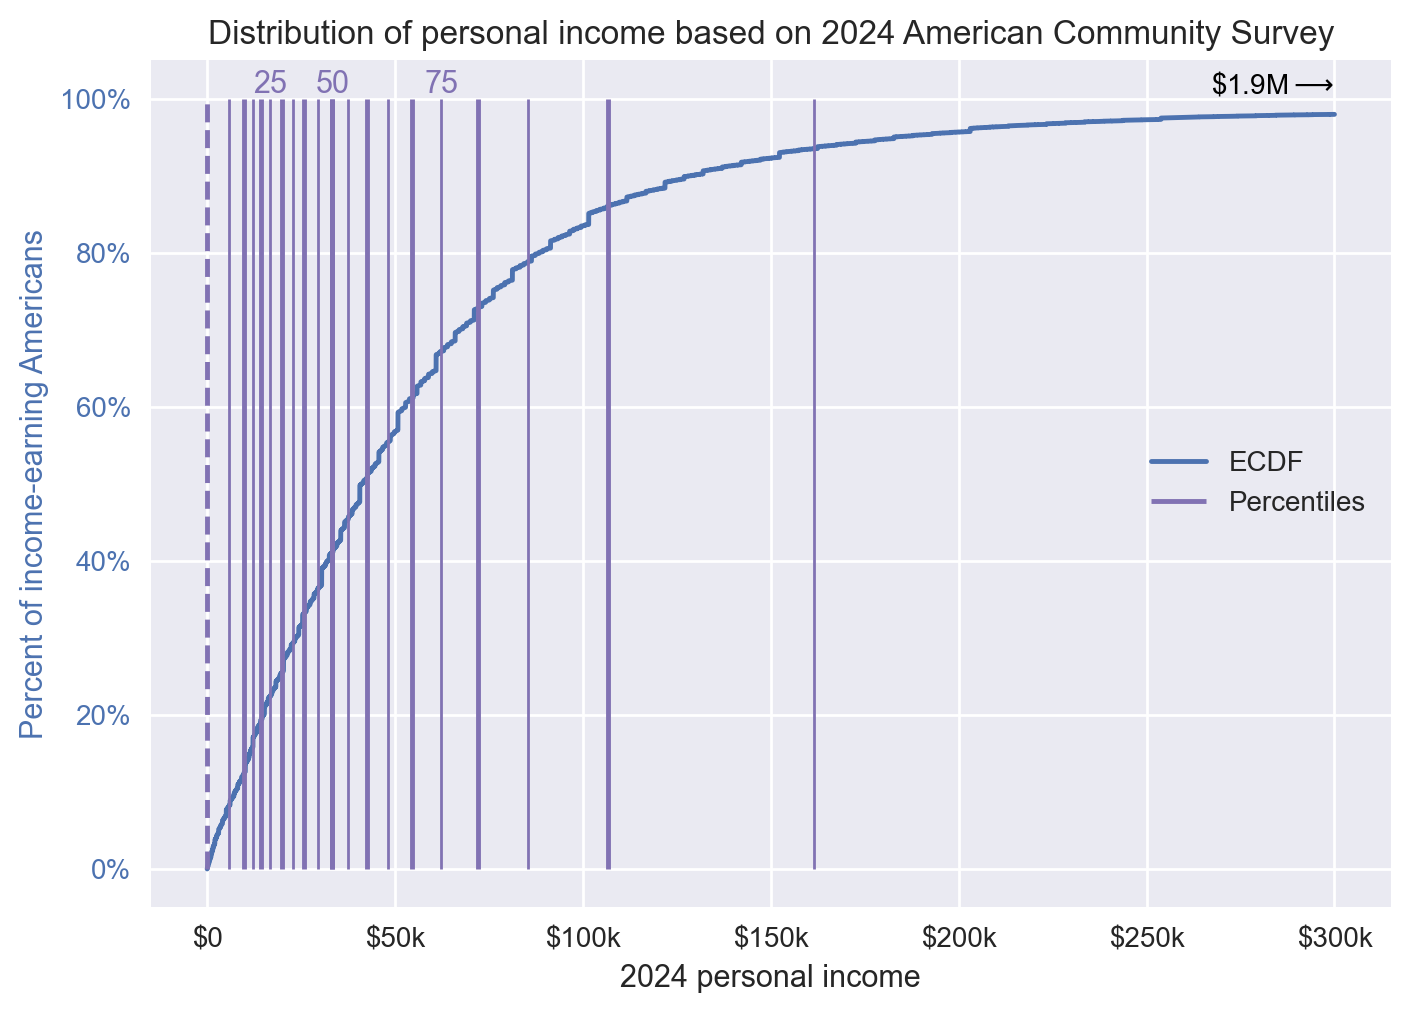

In [50]:
limit = 300_000
subset = data[data.inc2024 < limit]
plt.plot(subset.inc2024, subset.pct, label='ECDF')

plt.vlines(deciles, ymin=0, ymax=1, color='#8172B3', label='Percentiles')
plt.vlines(median, ymin=0, ymax=1, color='#8172B3')
plt.vlines(fives, ymin=0, ymax=1, color='#8172B3', linewidth=1)
plt.vlines([data.inc2024.min()], ymin=0, ymax=1, color='#8172B3', linestyle='dashed')

plt.text(y=1, x=list(median)[0],
    s=f'50',
    ha='center', va='bottom',
    color='#8172B3', fontsize=11)
plt.text(y=1, x=list(quartiles)[0],
    s=f'25',
    ha='center', va='bottom',
    color='#8172B3', fontsize=11)
plt.text(y=1, x=list(quartiles)[1],
    s=f'75',
    ha='center', va='bottom',
    color='#8172B3', fontsize=11)
plt.text(y=1, x=300_000,
    s='\$1.9M$\longrightarrow$',
    ha='right', va='bottom',
    color='black', fontsize=10)

plt.legend(loc='center right')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k' if x != 0 else '$0'))
plt.xlabel('2024 personal income')
plt.title('Distribution of personal income based on 2024 American Community Survey')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.ylabel('Percent of income-earning Americans', color='#4C72B0')
plt.gca().tick_params(axis='y', colors='#4C72B0')

plt.show()

<>:35: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:35: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
/var/folders/3n/v6kbxqb94b92ys1nm0gbhrvm0000gn/T/ipykernel_23842/974938031.py:35: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  s='\$1.9M$\longrightarrow$',


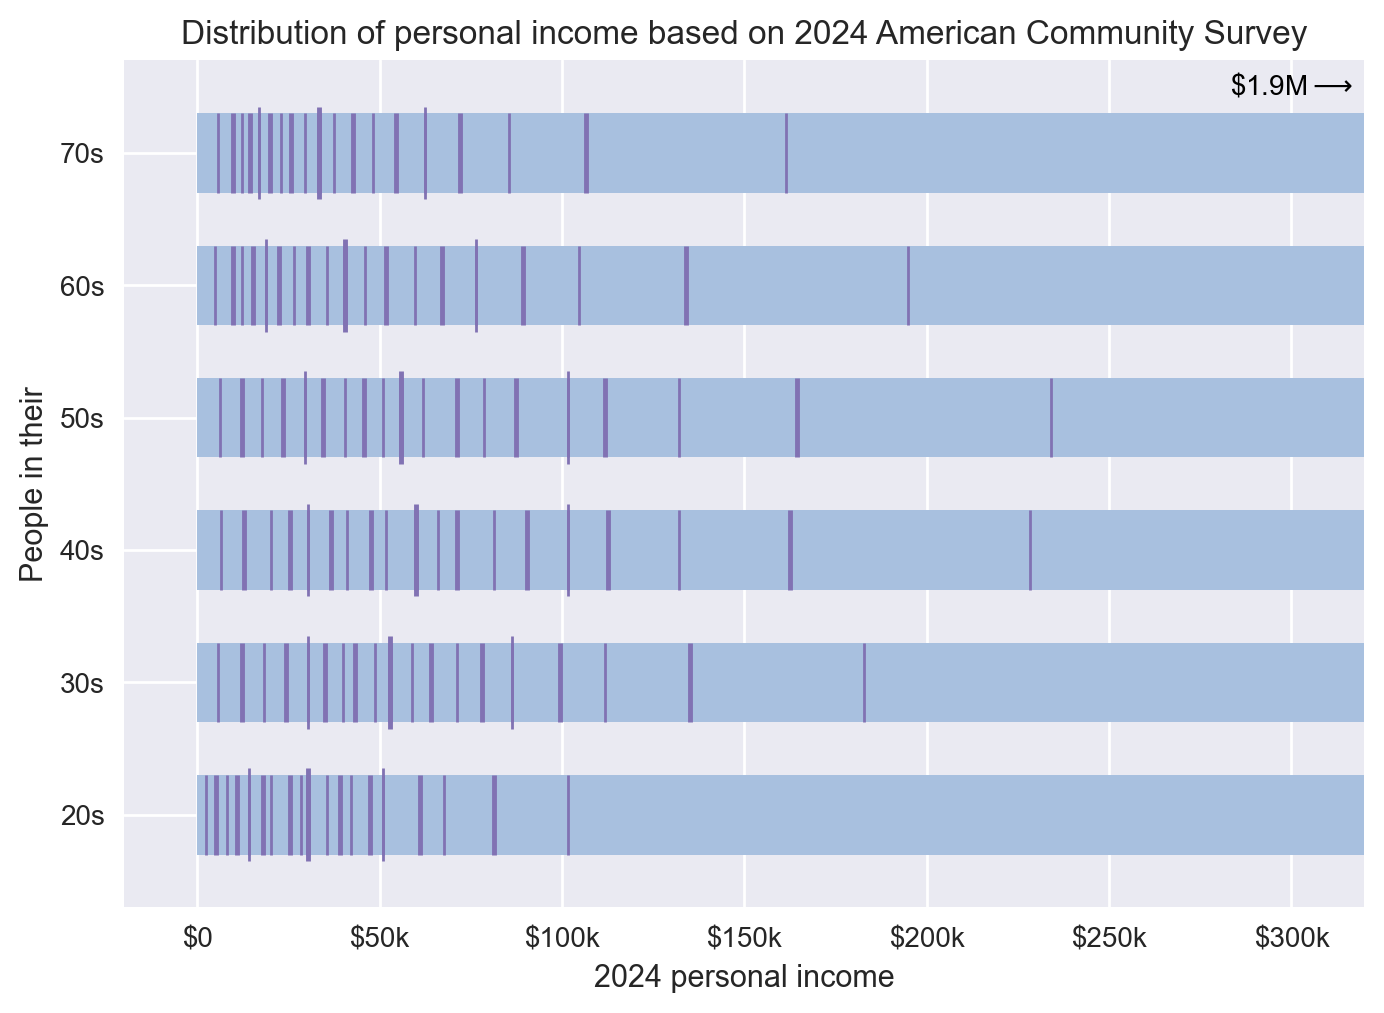

In [56]:
decile_breaks = np.arange(0.1, 1.0, 0.1)
five_breaks = np.arange(0.05, 1.0, 0.1)

height = 6

fig, ax = plt.subplots()

for index in range(6):
#for cat, grp in df.groupby('category'):
    group = data.AGEP // 10 == (index + 2)
    subset = data[group]
    age = (index + 2) * 10
    d = DescrStatsW(subset.inc2024, weights=subset.PWGTP)
    deciles = d.quantile(decile_breaks)
    fives = d.quantile(five_breaks)
    median = d.quantile(0.5)
    quartiles = d.quantile([0.25, 0.75])
    left, right = subset.inc2024.min(), subset.inc2024.max()
    rect = patches.Rectangle(
            (left, age - height/2),          # bottom-left corner
            right - left, height,   # dimensions
            linewidth=1,
            edgecolor='none',
            facecolor='#A8C0DF',
            alpha=1.0         # opacity: 0.0 = transparent, 1.0 = opaque
            )
    ax.add_patch(rect)
    plt.vlines(deciles, ymin=age - height/2, ymax=age + height/2, color='#8172B3')
    plt.vlines(median, ymin=age - (height+1)/2, ymax=age + (height+1)/2, color='#8172B3')
    plt.vlines(fives, ymin=age - height/2, ymax=age + height/2, color='#8172B3', linewidth=1)
    plt.vlines(quartiles, ymin=age - (height+1)/2, ymax=age + (height+1)/2, color='#8172B3', linewidth=1)
#    plt.vlines([left, right], ymin=age - height/2, ymax=age + height/2, color='#8172B3', linestyle='dashed')

plt.text(y=74, x=300_000,
    s='\$1.9M$\longrightarrow$',
    ha='center', va='bottom',
    color='black', fontsize=10)

plt.ylim([13, 77])
plt.xlim([-50_000, 2_050_000])
plt.xlim([-20_000, 320_000])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k' if x != 0 else '$0'))
plt.xlabel('2024 personal income')
plt.ylabel('People in their')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}s'))
plt.title('Distribution of personal income based on 2024 American Community Survey')

plt.show()

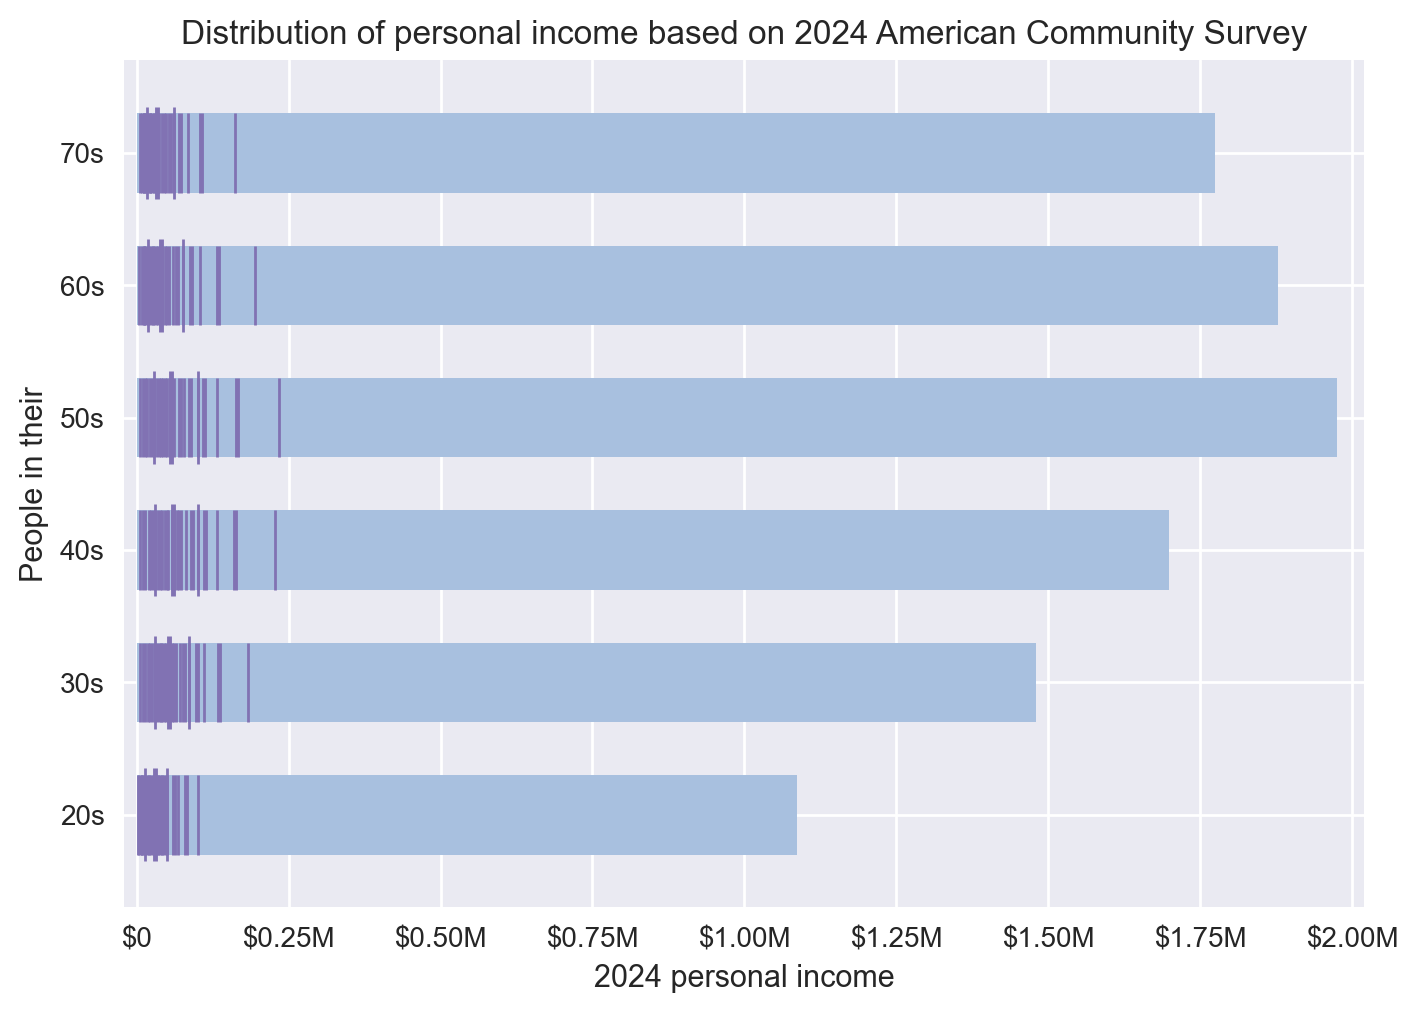

In [57]:
decile_breaks = np.arange(0.1, 1.0, 0.1)
five_breaks = np.arange(0.05, 1.0, 0.1)

height = 6

fig, ax = plt.subplots()

for index in range(6):
#for cat, grp in df.groupby('category'):
    group = data.AGEP // 10 == (index + 2)
    subset = data[group]
    age = (index + 2) * 10
    d = DescrStatsW(subset.inc2024, weights=subset.PWGTP)
    deciles = d.quantile(decile_breaks)
    fives = d.quantile(five_breaks)
    median = d.quantile(0.5)
    quartiles = d.quantile([0.25, 0.75])
    left, right = subset.inc2024.min(), subset.inc2024.max()
    rect = patches.Rectangle(
            (left, age - height/2),          # bottom-left corner
            right - left, height,   # dimensions
            linewidth=1,
            edgecolor='none',
            facecolor='#A8C0DF',
            alpha=1.0         # opacity: 0.0 = transparent, 1.0 = opaque
            )
    ax.add_patch(rect)
    plt.vlines(deciles, ymin=age - height/2, ymax=age + height/2, color='#8172B3')
    plt.vlines(median, ymin=age - (height+1)/2, ymax=age + (height+1)/2, color='#8172B3')
    plt.vlines(fives, ymin=age - height/2, ymax=age + height/2, color='#8172B3', linewidth=1)
    plt.vlines(quartiles, ymin=age - (height+1)/2, ymax=age + (height+1)/2, color='#8172B3', linewidth=1)
#    plt.vlines([left, right], ymin=age - height/2, ymax=age + height/2, color='#8172B3', linestyle='dashed')

#plt.text(y=74, x=300_000,
#    s='\$1.9M$\longrightarrow$',
#    ha='center', va='bottom',
#    color='black', fontsize=10)

plt.ylim([13, 77])
plt.xlim([-50_000, 2_050_000])
plt.xlim([-20_000, 2_020_000])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${(x/1_000_000):.2f}M' if x != 0 else '$0'))
plt.xlabel('2024 personal income')
plt.ylabel('People in their')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}s'))
plt.title('Distribution of personal income based on 2024 American Community Survey')

plt.show()

<>:46: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:46: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
/var/folders/3n/v6kbxqb94b92ys1nm0gbhrvm0000gn/T/ipykernel_23842/107568510.py:46: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  s='\$1.9M$\longrightarrow$',


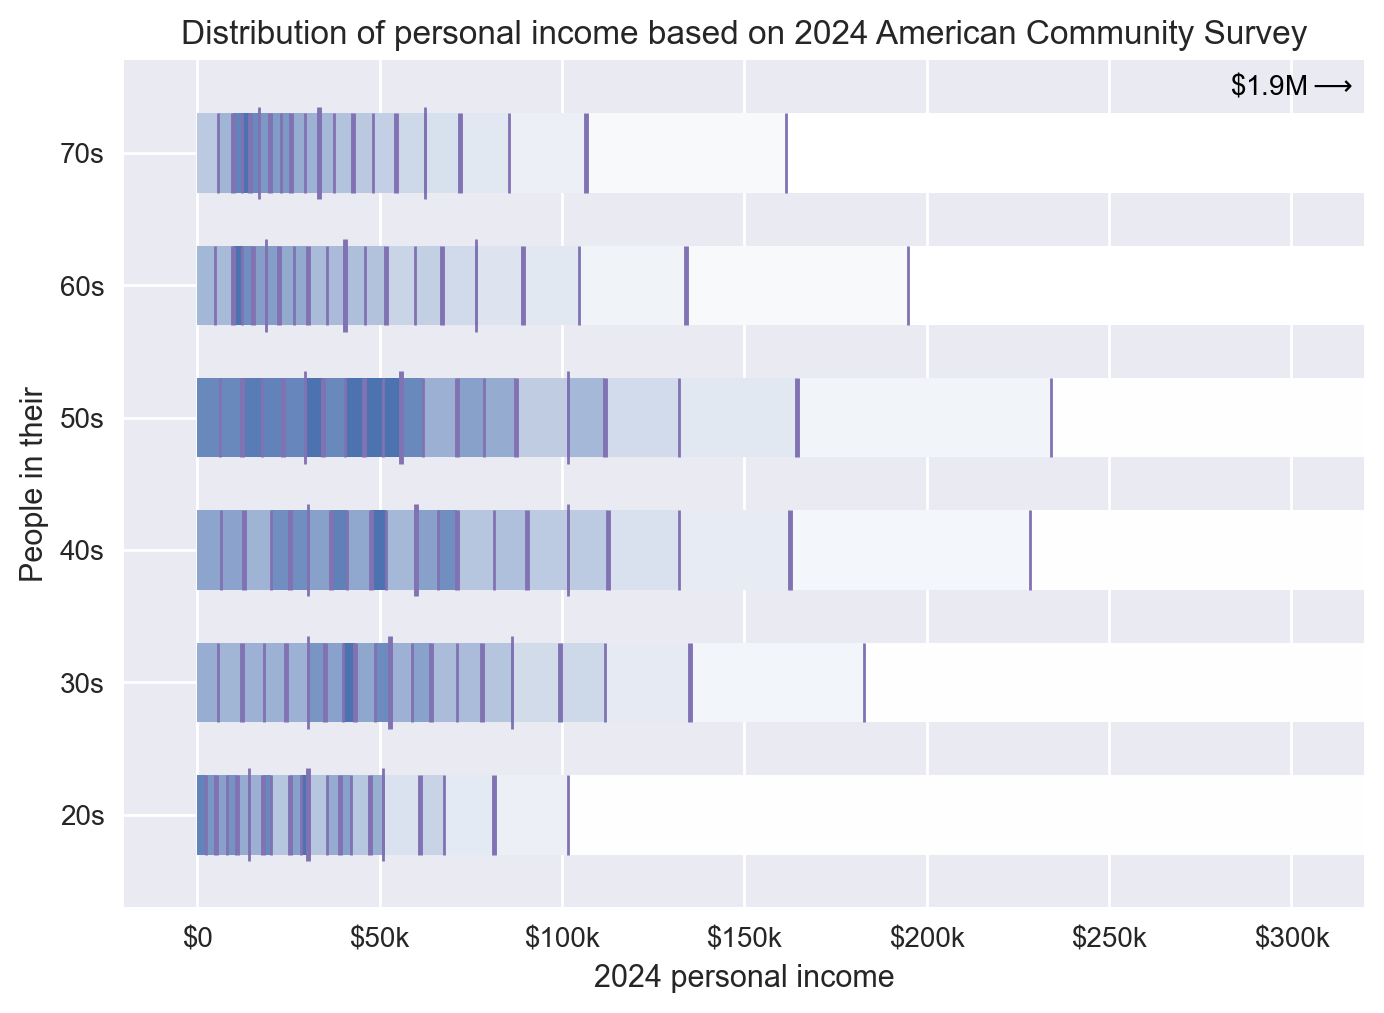

In [74]:
decile_breaks = np.arange(0.1, 1.0, 0.1)
five_breaks = np.arange(0.05, 1.0, 0.1)
tight_breaks = np.arange(0.05, 1.0, 0.05)

height = 6

fig, ax = plt.subplots()

for index in range(6):
#for cat, grp in df.groupby('category'):
    group = data.AGEP // 10 == (index + 2)
    subset = data[group]
    age = (index + 2) * 10
    d = DescrStatsW(subset.inc2024, weights=subset.PWGTP)
    deciles = d.quantile(decile_breaks)
    fives = d.quantile(five_breaks)
    median = d.quantile(0.5)
    quartiles = d.quantile([0.25, 0.75])
    left, right = subset.inc2024.min(), subset.inc2024.max()
    rect = patches.Rectangle(
            (left, age - height/2),          # bottom-left corner
            right - left, height,   # dimensions
            linewidth=1,
            edgecolor='none',
            facecolor='white',  # #A8C0DF
            alpha=1.0         # opacity: 0.0 = transparent, 1.0 = opaque
            )
    ax.add_patch(rect)
    all_breaks = [subset.inc2024.min()] + list(d.quantile(tight_breaks)) + [subset.inc2024.max()]
    widths = [all_breaks[index + 1] - all_breaks[index] for index in range(len(all_breaks) - 1)]
    min_width = min(widths)
    for index in range(len(widths)):
        #print(all_breaks[index])
        rect = patches.Rectangle((all_breaks[index], age - height/2),
                                 widths[index], height,
                                 linewidth=1, edgecolor='none',
                                 facecolor='#4C72B0', alpha=(min_width / widths[index]))#**0.5)
        ax.add_patch(rect)
    plt.vlines(deciles, ymin=age - height/2, ymax=age + height/2, color='#8172B3')
    plt.vlines(median, ymin=age - (height+1)/2, ymax=age + (height+1)/2, color='#8172B3')
    plt.vlines(fives, ymin=age - height/2, ymax=age + height/2, color='#8172B3', linewidth=1)
    plt.vlines(quartiles, ymin=age - (height+1)/2, ymax=age + (height+1)/2, color='#8172B3', linewidth=1)
#    plt.vlines([left, right], ymin=age - height/2, ymax=age + height/2, color='#8172B3', linestyle='dashed')

plt.text(y=74, x=300_000,
    s='\$1.9M$\longrightarrow$',
    ha='center', va='bottom',
    color='black', fontsize=10)

plt.ylim([13, 77])
plt.xlim([-50_000, 2_050_000])
plt.xlim([-20_000, 320_000])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k' if x != 0 else '$0'))
plt.xlabel('2024 personal income')
plt.ylabel('People in their')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}s'))
plt.title('Distribution of personal income based on 2024 American Community Survey')

plt.show()

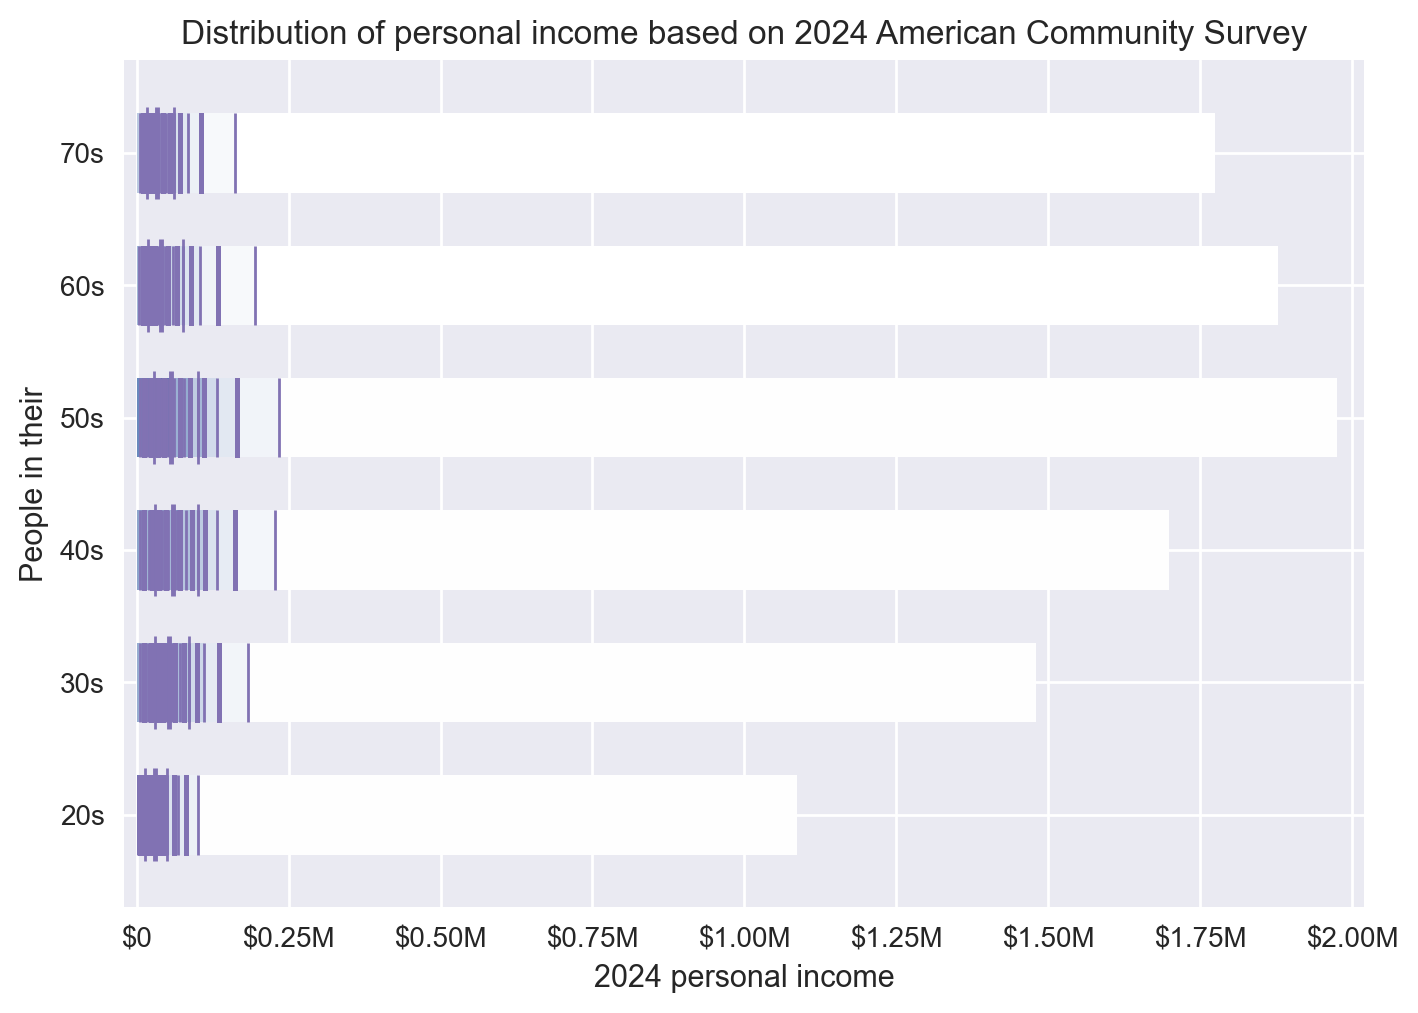

In [72]:
decile_breaks = np.arange(0.1, 1.0, 0.1)
five_breaks = np.arange(0.05, 1.0, 0.1)

height = 6

fig, ax = plt.subplots()

for index in range(6):
#for cat, grp in df.groupby('category'):
    group = data.AGEP // 10 == (index + 2)
    subset = data[group]
    age = (index + 2) * 10
    d = DescrStatsW(subset.inc2024, weights=subset.PWGTP)
    deciles = d.quantile(decile_breaks)
    fives = d.quantile(five_breaks)
    median = d.quantile(0.5)
    quartiles = d.quantile([0.25, 0.75])
    left, right = subset.inc2024.min(), subset.inc2024.max()
    rect = patches.Rectangle(
            (left, age - height/2),          # bottom-left corner
            right - left, height,   # dimensions
            linewidth=1,
            edgecolor='none',
            facecolor='white', #A8C0DF
            alpha=1.0         # opacity: 0.0 = transparent, 1.0 = opaque
            )
    ax.add_patch(rect)
    all_breaks = [subset.inc2024.min()] + list(d.quantile(tight_breaks)) + [subset.inc2024.max()]
    widths = [all_breaks[index + 1] - all_breaks[index] for index in range(len(all_breaks) - 1)]
    min_width = min(widths)
    for index in range(len(widths)):
        #print(all_breaks[index])
        rect = patches.Rectangle((all_breaks[index], age - height/2),
                                 widths[index], height,
                                 linewidth=1, edgecolor='none',
                                 facecolor='#4C72B0', alpha=min_width / widths[index])
        ax.add_patch(rect)
        plt.vlines(deciles, ymin=age - height/2, ymax=age + height/2, color='#8172B3')
    plt.vlines(median, ymin=age - (height+1)/2, ymax=age + (height+1)/2, color='#8172B3')
    plt.vlines(fives, ymin=age - height/2, ymax=age + height/2, color='#8172B3', linewidth=1)
    plt.vlines(quartiles, ymin=age - (height+1)/2, ymax=age + (height+1)/2, color='#8172B3', linewidth=1)
#    plt.vlines([left, right], ymin=age - height/2, ymax=age + height/2, color='#8172B3', linestyle='dashed')

#plt.text(y=74, x=300_000,
#    s='\$1.9M$\longrightarrow$',
#    ha='center', va='bottom',
#    color='black', fontsize=10)

plt.ylim([13, 77])
plt.xlim([-50_000, 2_050_000])
plt.xlim([-20_000, 2_020_000])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${(x/1_000_000):.2f}M' if x != 0 else '$0'))
plt.xlabel('2024 personal income')
plt.ylabel('People in their')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}s'))
plt.title('Distribution of personal income based on 2024 American Community Survey')

plt.show()